In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import os, sys
import numpy as np 
# import pandas as pd 
import matplotlib.pyplot as plt
# import geopandas as gpd
import sklearn
# from sklearn.cross_decomposition import CCA
import copy

from scipy.cluster.hierarchy import dendrogram, linkage
from tqdm import tqdm
sys.path.append('../src/')
sys.path.append('../content/')
import data_utils as du
import vis_utils as vu
import loadpaths
path_dict_pecl = loadpaths.loadpaths()
import analysis_utils as au


In [60]:
sentinel, sentinel_eq, features, hypotheses = du.load_all_data(zscore_features=False, 
                                                               complete_only=True, nancheck=True,
                                                               nonnan_only=True,
                                    path_folder='/Users/tplas/data/2025-10 neureo/pecl-100-subsample-30km_v2',
                                        zscore_hypotheses=False, equalize_sentinel=True)

features_all = np.stack(features, axis=0)
features_all = au.ravel_features(features_all)

100%|██████████| 500/500 [00:02<00:00, 204.32it/s]


Loaded 100 patches from /Users/tplas/data/2025-10 neureo/pecl-100-subsample-30km_v2, no NaNs or Infs found.


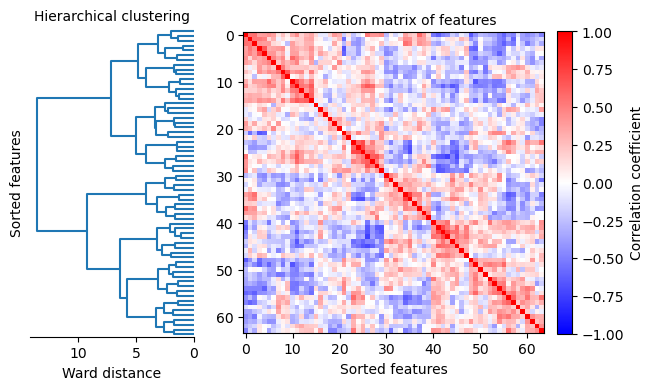

In [63]:
## Hierarchical clustering of correlation mat features
corr_mat = np.corrcoef(features_all)
Z = linkage(corr_mat, 'ward')

fig, ax = plt.subplots(1, 2, figsize=(7, 4), gridspec_kw={'width_ratios': [1, 2], 'hspace': 0.0})

dendro = dendrogram(Z, orientation='left', leaf_rotation=0., 
                    leaf_font_size=8., ax=ax[0], color_threshold=0,
                    leaf_label_func=lambda x: str() if x % 10 == 0 else '')


# sorted_feature_inds = np.array(dendro['leaves'])
sorted_feature_inds = np.load('../outputs/inds_sorted_features.npy')
# np.save('../outputs/inds_sorted_features.npy', sorted_feature_inds)
assert all(sorted_feature_inds == np.array(dendro['leaves']))
ax[0].set_title('Hierarchical clustering', fontsize=10)
ax[0].set_xlabel('Ward distance')
ax[0].set_ylabel('Sorted features')
ax[0].invert_yaxis()
for sp in ['left', 'top', 'right']:
    ax[0].spines[sp].set_visible(False)


corr_mat_sorted = corr_mat[sorted_feature_inds, :][:, sorted_feature_inds]
ax[1].imshow(corr_mat_sorted, vmin=-1, vmax=1, cmap='bwr')
ax[1].set_xlabel('Sorted features')
ax[1].set_title('Correlation matrix of features', fontsize=10)
## cbar
cbar = plt.colorbar(mappable=ax[1].images[0], ax=ax[1], fraction=0.046, pad=0.04, label='Correlation coefficient')


In [173]:
# ## Calculate PCA dim by subsampling from 176-patch dataset:
# patches = 200
# features_pca = []
# for p in range(patches):
#     (data_sent, data_alpha, data_dyn, data_worldclim, data_dsm) = du.load_all_modalities_from_name(name=f'pecl176-{p}', 
#                                 path_folder='/Users/tplas/data/2025-10 neureo/pecl-176-subsample-30km_v2', verbose=0)
    
#     if data_alpha is None:
#         continue
#     f_dat = data_alpha.data
#     f_dat[~np.isfinite(f_dat)] = np.nan
#     features_pca.append(f_dat)

_, __, features_pca, ___ = du.load_all_data(zscore_features=False, 
                                        zscore_hypotheses=False, equalize_sentinel=True,
                                        complete_only=True, nancheck=True, nonnan_only=True,
                                        path_folder='/Users/tplas/data/2025-10 neureo/pecl-176-subsample-30km_v2')

features_pca = np.stack(features_pca, axis=0)

dict_dim, dict_expl_var = au.calculate_pca_dim(features_pca)
print(f'Mean dims: {[(k, float(np.round(np.mean(dict_dim[k]), 1))) for k in dict_dim]}')

100%|██████████| 869/869 [00:05<00:00, 155.28it/s] 


Loaded 165 patches from /Users/tplas/data/2025-10 neureo/pecl-176-subsample-30km_v2, no NaNs or Infs found.


100%|██████████| 20/20 [00:10<00:00,  1.82it/s]

Mean dims: [(1, 4.3), (5, 5.5), (10, 7.4), (50, 8.8), (100, 9.1)]


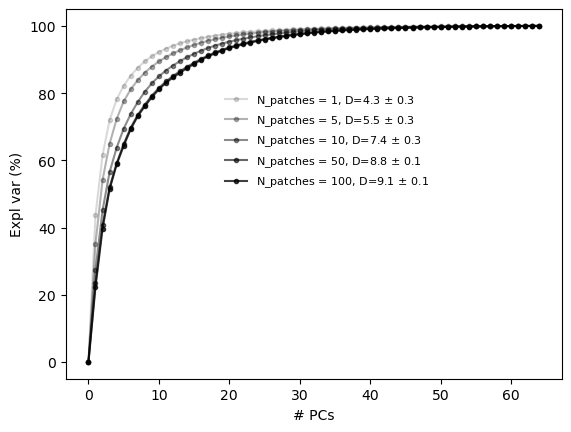

In [174]:
vu.plot_pca_dim(dict_expl_var=dict_expl_var, dict_dim=dict_dim)

(100, 64)


Text(0.5, 0, 'Sorted features')

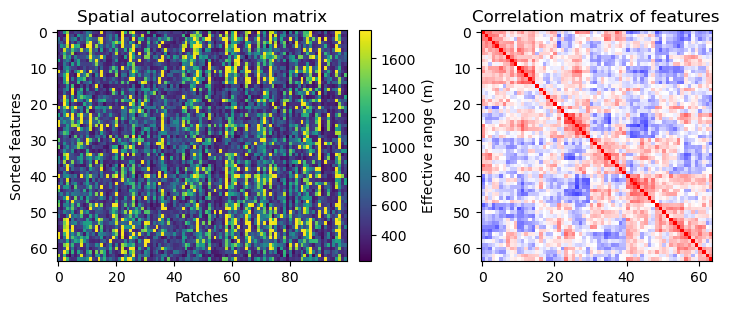

In [64]:
## Spatial autocorr
mat_effective_range = np.load('../outputs/spatial_autocorr_pecl100-30km_spherical_4000_2000.npy')
print(mat_effective_range.shape)
mat_effective_range_sorted = mat_effective_range[:, sorted_feature_inds].T

fig, ax = plt.subplots(1, 2, figsize=(9, 3), gridspec_kw={'width_ratios': [1, 1], 'hspace': 0.5})

im0 = ax[0].imshow(mat_effective_range_sorted, cmap='viridis', aspect='auto', interpolation='none')
ax[0].set_title('Spatial autocorrelation matrix')
cbar0 = plt.colorbar(im0, ax=ax[0], fraction=0.046, pad=0.04, label='Effective range (m)')
ax[0].set_xlabel('Patches')
ax[0].set_ylabel('Sorted features')

im1 = ax[1].imshow(corr_mat_sorted, vmin=-1, vmax=1, cmap='bwr')
ax[1].set_title('Correlation matrix of features')
# cbar1 = plt.colorbar(im1, ax=ax[1], fraction=0.046, pad=0.04, label='Correlation coefficient')
ax[1].set_xlabel('Sorted features')

Text(0, 0.5, 'Feature')

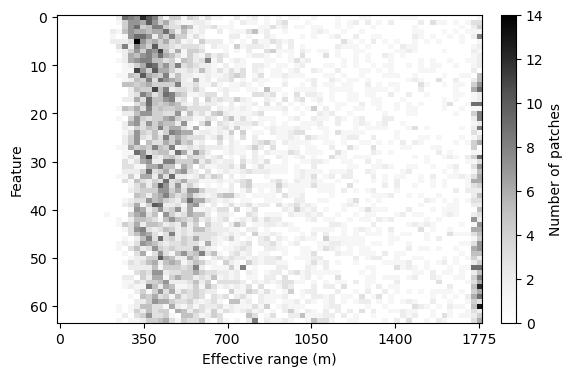

In [65]:
tmp = copy.deepcopy(mat_effective_range_sorted)
tmp[tmp > 1680] = np.nan
medians = np.nanmedian(tmp, 1)  # medians while ignoring highest band
inds_median_range_sort = np.argsort(medians)

bin_dist = 25  # in metres
min_range = 0
max_range = mat_effective_range_sorted.max()
# bin_edges = np.linspace(min_range, max_range, bins_effective_range.shape[0] + 1)
bin_edges = np.arange(min_range, max_range + bin_dist, bin_dist)
bins_effective_range = np.zeros((len(bin_edges) - 1, 64))
for i in range(bins_effective_range.shape[0]):
    bins_effective_range[i, :] = np.sum((mat_effective_range_sorted >= bin_edges[i]) & (mat_effective_range_sorted < bin_edges[i+1]), axis=1)

fig, ax = plt.subplots(1, 1, figsize=(6, 4))
im = ax.imshow(bins_effective_range.T[inds_median_range_sort, :], aspect='auto', cmap='Grays')
cbar = plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04, label='Number of patches')
xticks_range_distr = np.linspace(0, bins_effective_range.shape[0]-1, 6)
xticklabels_range_distr = [f'{int(bin_edges[int(x)]):d}' for x in xticks_range_distr]
ax.set_xticks(xticks_range_distr)
# ax.set_xlim(8, 40)
ax.set_xticklabels(xticklabels_range_distr)
ax.set_xlabel('Effective range (m)')
ax.set_ylabel('Feature')

Text(0.5, 0, 'Effective range (m)')

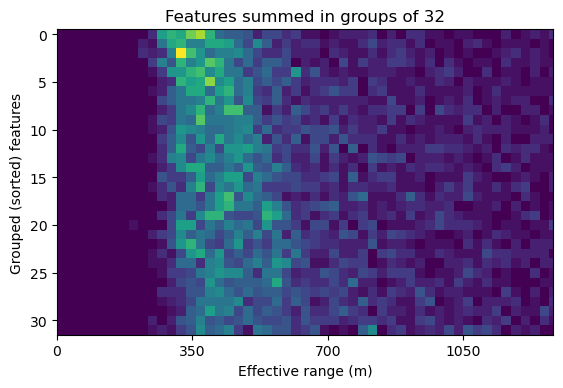

In [66]:
tmp = bins_effective_range.T[inds_median_range_sort, :]
features_range = copy.deepcopy(tmp)
n_summary = 32
assert tmp.shape[0] % n_summary == 0
stepsize = int(tmp.shape[0] / n_summary)
features_aggr_range = np.zeros((n_summary, tmp.shape[1]))
for ii in range(n_summary):
    features_aggr_range[ii, :] = np.sum(tmp[ii * stepsize:(ii + 1) * stepsize, :], 0)

fig, ax = plt.subplots(1, 1)
ax.imshow(features_aggr_range)
ax.set_ylabel('Grouped (sorted) features')
ax.set_title(f'Features summed in groups of {n_summary}')
ax.set_xticks(xticks_range_distr)
ax.set_xticklabels(xticklabels_range_distr)
ax.set_xlim([0, 52])
ax.set_xlabel('Effective range (m)')

0.9594


Text(0.02644530516598117, 22, 'Percentile: 0.959')

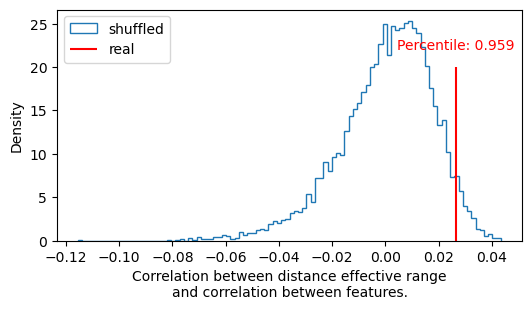

In [68]:
n_feat = len(medians)

dist_medians = -1 * np.abs(medians[:, None] - medians[None, :])  # matrix of distances (=abs difference between medians)
inds_upper_tr = np.triu_indices_from(dist_medians, k=1)  # get indices of upper triangle excl diag
arr_dist_medians = dist_medians[inds_upper_tr]
arr_corr = corr_mat_sorted[inds_upper_tr]
# np.corrcoef(arr_dist_medians, arr_corr)[0, 1]

n_perm = 10000  # permutations for shuffling
n_vals = len(arr_dist_medians)
shuffled_corr = []
for ii in range(n_perm):
    inds_shuffle_rows = np.random.choice(n_feat, n_feat, replace=False)
    shuffled_medians = copy.deepcopy(medians)
    shuffled_medians = shuffled_medians[inds_shuffle_rows]  # shuffle medians (ie feature inds)
    shuffled_dist = np.abs(shuffled_medians[:, None] - shuffled_medians[None, :])  # shuffled dist mat
    shuffled_arr_dist = shuffled_dist[inds_upper_tr]
    shuffled_corr.append(float(np.corrcoef(shuffled_arr_dist, arr_corr)[0, 1]))

fig, ax = plt.subplots(1, 1, figsize=(6, 3))
ax.hist(shuffled_corr, bins=100, histtype='step', label='shuffled', density=True);
ax.set_xlabel('Correlation between distance effective range\nand correlation between features.')
ax.set_ylabel('Density')

corr_real = np.corrcoef(arr_dist_medians, arr_corr)[0, 1]
ax.vlines(x=corr_real, ymin=0, ymax=20, color='red', label='real')
ax.legend()

percentile = np.argmin(np.abs(np.sort(shuffled_corr) - corr_real)) / len(shuffled_corr)
print(percentile)

ax.annotate(text=f'Percentile: {np.round(percentile, 3)}', xy=(corr_real, 22), ha='center', color='red')

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0015..1.5].


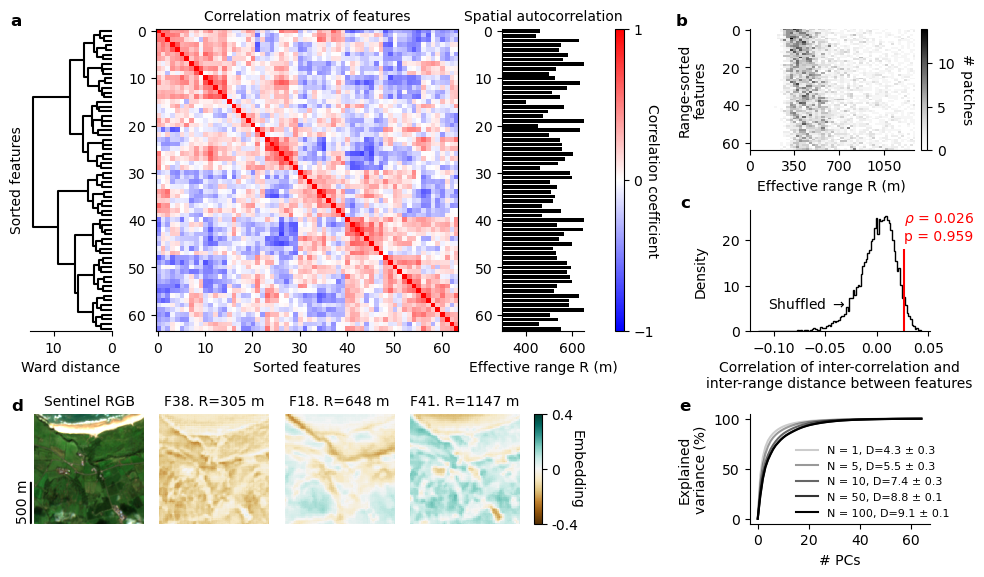

In [ ]:
save_fig = False

fig = plt.figure(figsize=(9, 5.5))

gs_topleft = fig.add_gridspec(1, 4, width_ratios=[1, 4, 1, 0.1], wspace=0.25, 
                           left=0, right=0.66, bottom=0.4, top=0.95)
gs_topright = fig.add_gridspec(2, 1, left=0.8, right=1, bottom=0.4, top=0.95, hspace=0.5)


i_feats = [38, 18, 41]

gs_bottomleft = fig.add_gridspec(1, len(i_feats) + 1, wspace=0.05, width_ratios=[1] * (len(i_feats) + 1),
                           left=0, right=0.55, bottom=0.05, top=0.25)
gs_cbar_bl = fig.add_gridspec(1, 1, 
                           left=0.56, right=0.569, bottom=0.05, top=0.25)
gs_bottomright = fig.add_gridspec(1, 1, left=0.8, right=1, bottom=0.05, top=0.25, hspace=0.5)

ax_left = [fig.add_subplot(gs_topleft[:, ii]) for ii in range(4)]
ax_right = [fig.add_subplot(gs_topright[ii, :]) for ii in range(2)]
ax_bottomleft = [fig.add_subplot(gs_bottomleft[:, ii]) for ii in range(gs_bottomleft.ncols)]
ax_cbar_bl = fig.add_subplot(gs_cbar_bl[:, :])
ax_bottomright = fig.add_subplot(gs_bottomright[:, :])

## Hierarchical clustering of features
corr_mat = np.corrcoef(features_all)
Z = linkage(corr_mat, 'ward')
dendro = dendrogram(Z, orientation='left', leaf_rotation=0., 
                    leaf_font_size=8., ax=ax_left[0], color_threshold=0,
                    above_threshold_color='k', #link_color_func=lambda k: colors_clusters[fcluster(Z, 7, criterion='maxclust')[k]] ,
                    leaf_label_func=lambda x: str() if x % 10 == 0 else '')
# ax_left[0].set_title('Hierarchical clustering', fontsize=10)
ax_left[0].set_xlabel('Ward distance')
ax_left[0].set_ylabel('Sorted features')
ax_left[0].invert_yaxis()
for sp in ['left', 'top', 'right']:
    ax_left[0].spines[sp].set_visible(False)


corr_mat_sorted = corr_mat[sorted_feature_inds, :][:, sorted_feature_inds]
ax_left[1].imshow(corr_mat_sorted, vmin=-1, vmax=1, cmap='bwr')
ax_left[1].set_xlabel('Sorted features')
ax_left[1].set_title('Correlation matrix of features', fontsize=10)
## cbar
cbar = plt.colorbar(mappable=ax_left[1].images[0], ax=ax_left[1], #fraction=0.046, pad=0.04, 
                    cax=ax_left[3], ticks=[-1, 0, 1],
                    label='Correlation coefficient')
ax_left[3].set_ylabel('Correlation coefficient', rotation=270)

ax_left[2].barh(np.arange(len(features_all)), medians, facecolor='k')
ax_left[2].set_xlim(300, 650)
ax_left[2].set_ylim(-0.5, 63.5)
ax_left[2].invert_yaxis()
ax_left[2].set_xlabel("Effective range R (m)")
ax_left[2].set_title("Spatial autocorrelation", fontsize=10)

ax_right[0].imshow(features_range, aspect='auto', interpolation='none', cmap='Grays', rasterized=True)
ax_right[0].set_ylabel('Range-sorted\nfeatures')
ax_right[0].set_xticks(xticks_range_distr)
ax_right[0].set_xticklabels(xticklabels_range_distr)
ax_right[0].set_xlim(0, 52)
ax_right[0].set_xlabel('Effective range R (m)')
cbar = plt.colorbar(mappable=ax_right[0].images[0], ax=ax_right[0], fraction=0.046, pad=0.04, label='# patches')
cbar.ax.set_ylabel('# patches', rotation=270, va='bottom')

ax_right[1].hist(shuffled_corr, bins=100, histtype='step', label='shuffled', density=True, color='k');
ax_right[1].set_xlabel('Correlation of inter-correlation and\ninter-range distance between features')
ax_right[1].set_ylabel('Density')

corr_real = np.corrcoef(arr_dist_medians, arr_corr)[0, 1]
ax_right[1].vlines(x=corr_real, ymin=0, ymax=18, color='red', label='real')
percentile = np.argmin(np.abs(np.sort(shuffled_corr) - corr_real)) / len(shuffled_corr)

ax_right[1].annotate(text=r"$\rho$" + f' = {np.round(corr_real, 3)} \np = {np.round(percentile, 3)}', xy=(corr_real, 20), ha='left', color='red')
ax_right[1].annotate(text='Shuffled ' + r"$\to$", xy=(-.105, 5))

i_patch_example = 96
# # i_feats = [38, 18, 41]
# i_feats = [38, 18, 41, 48]

ax_bottomleft[0].imshow(np.clip(np.swapaxes(np.swapaxes(sentinel[i_patch_example][:3], 0, 2), 0, 1), 0, 3000) / 2000)
# vu.plot_sentinel(sentinel_eq[i_patch_example], ax=ax_bottomleft[0])
ax_bottomleft[0].set_title(f'Sentinel RGB', fontsize=10)

for i_plot, i_f in enumerate(i_feats):
    vu.plot_feature(features[i_patch_example][i_f], ax=ax_bottomleft[i_plot + 1], lim_zscore=False)
    ax_bottomleft[i_plot + 1].set_title(f'F{i_f}. R={int(mat_effective_range[i_patch_example][i_f])} m', fontsize=10)

ind_cax = i_plot + 2
cbar = plt.colorbar(mappable=ax_bottomleft[1].images[0], ax=ax_bottomleft[i_plot + 1], #fraction=0.046, pad=0.04, 
                    # cax=ax_bottomleft[ind_cax])
                    cax=ax_cbar_bl)
ax_cbar_bl.set_ylabel('Embedding', rotation=270)
ax_cbar_bl.set_yticks([-0.4, 0, 0.4])
ax_cbar_bl.set_yticklabels([-0.4, 0, 0.4])
# ax_bottomleft[ind_cax].set_yticklabels([r"$\frac{-1}{2}$ ", '0   ', r"$\frac{1}{2}$ "])

## add scalebar
vu.add_scalebar(ax=ax_bottomleft[0], location='bottom left vertical', fraction=0.5 / 1.28, label='500 m')

for i_n, n in enumerate([1, 5, 10, 50, 100]):
    dim_mean = np.mean(dict_dim[n])
    dim_sem = np.std(dict_dim[n]) / np.sqrt(len(dict_dim[n]))
    ax_bottomright.plot(np.concatenate([[0], dict_expl_var[n].mean(0)]) * 100, c='k', alpha=(i_n + 1) * 0.2,
             label=f'N = {n}, D={np.round(dim_mean, 1)}' + f' ± {np.round(dim_sem, 1)}')
ax_bottomright.set_xlabel('# PCs')
ax_bottomright.set_ylabel('Explained\nvariance (%)')
ax_bottomright.legend(frameon=False, bbox_to_anchor=(0.2, 0.8), fontsize=8)


for ax in ax_right:
    vu.despine(ax)
for ax in ax_bottomleft[:5]:
    vu.naked(ax)
vu.despine(ax_left[2])
vu.despine(ax_bottomright)

fig.align_ylabels(ax_right + [ax_bottomright])
fig.align_xlabels(ax_left)
# fig.align_ylabels([ax_left[-1], ax_bottomleft[-1]])

sys.path.append('/Users/tplas/repos/reproducible_figures/scripts')
import rep_fig_vis as rfv

rfv.add_panel_label(ax=ax_left[0], x_offset=-0.1, label_letter='a', fontsize=12)
rfv.add_panel_label(ax=ax_right[0], x_offset=4, label_letter='b', fontsize=12)
rfv.add_panel_label(ax=ax_right[1], x_offset=3.67, label_letter='c', fontsize=12)
rfv.add_panel_label(ax=ax_bottomleft[0], x_offset=-0.1, label_letter='d', fontsize=12)
rfv.add_panel_label(ax=ax_bottomright, x_offset=3.67, label_letter='e', fontsize=12)

if save_fig:
    plt.savefig('../../ms_neureo/figs/fig1.pdf', bbox_inches='tight')
    plt.savefig('../figs/fig1.pdf', bbox_inches='tight')

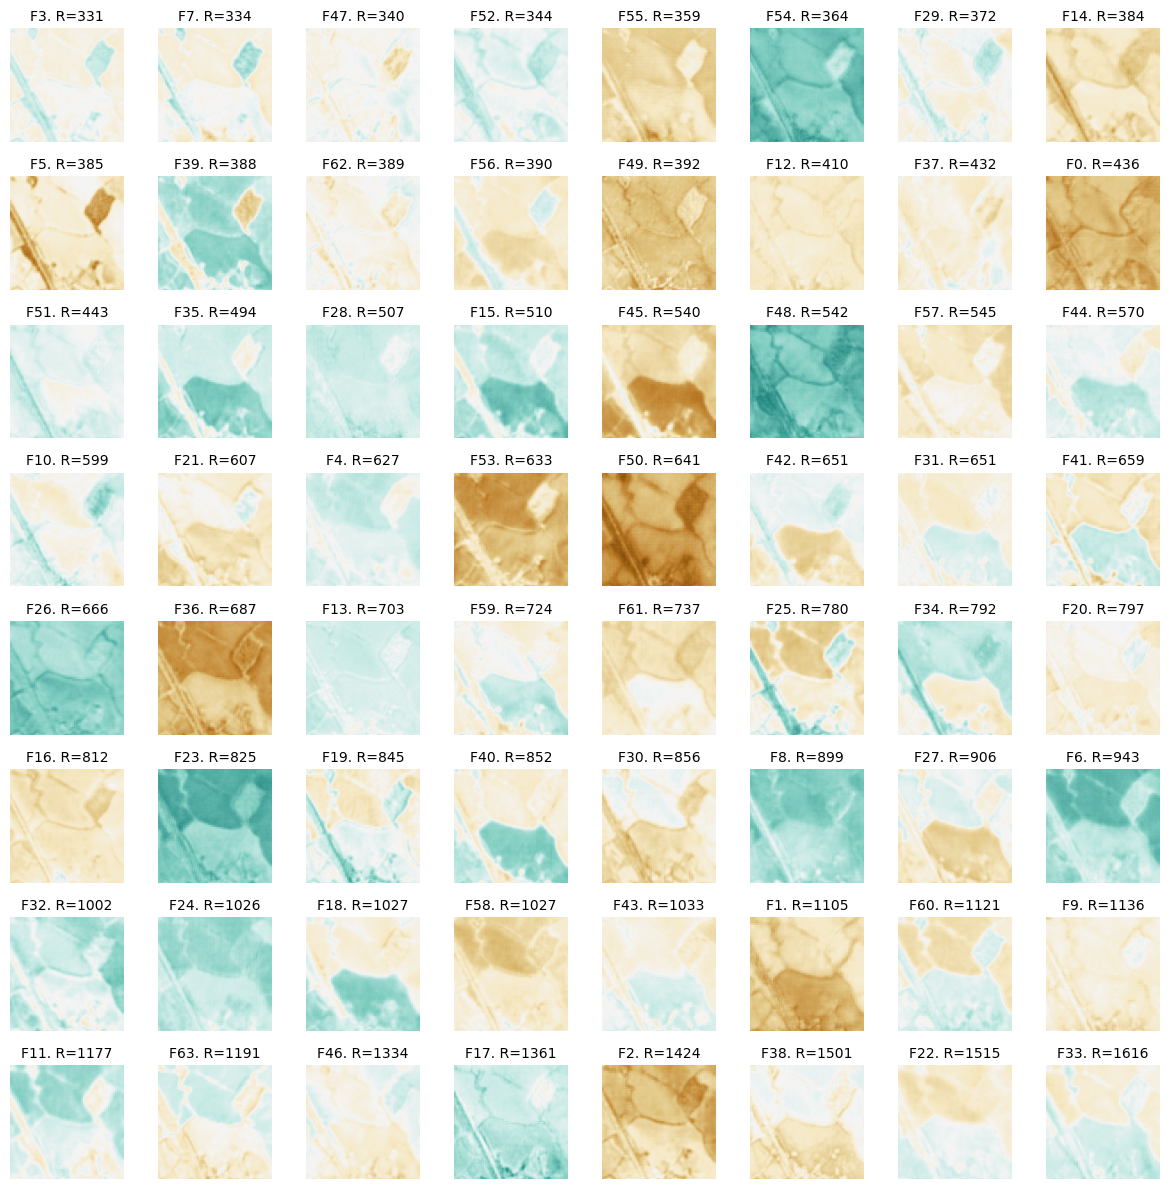

In [ ]:
np.argsort(mat_effective_range[i_patch_example])
i_patch_example = 23
fig, ax = plt.subplots(8, 8, figsize=(12, 12))
ax = ax.ravel() 

## Plot all features of example patch
for i in range(64):
    ind_feat = np.argsort(mat_effective_range[i_patch_example])[i]
    ax[i].imshow(features[i_patch_example][ind_feat], vmin=-lim, vmax=lim, cmap='BrBG')
    ax[i].set_title(f'F{ind_feat}. R={int(mat_effective_range[i_patch_example][ind_feat])}', fontsize=10)
    vu.naked(ax[i])
plt.tight_layout()

## Archive:

Effective range: 927.0


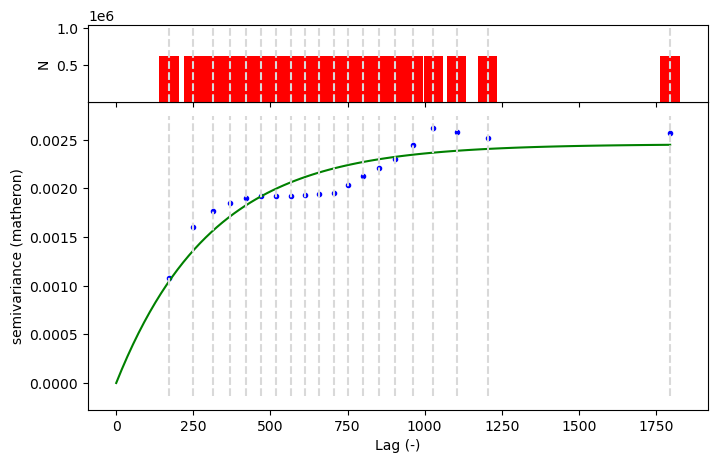

In [5]:
from spatial_autocorr import compute_range_for_band 

V, eff_range = compute_range_for_band(features[0][6], 10, n_subsample=5000, bin_func='uniform',
                                       model='exponential', maxlag=12080)
_ = V.plot()
print(f'Effective range: {np.round(eff_range)}')

In [ ]:
## Moran I:

from libpysal.weights import lat2W
from esda.moran import Moran
from splot.esda import moran_scatterplot

n_features = len(features[0])
n_patches = len(features)
assert n_features == 64 and n_patches == 100

## Take 30 mins:
## -----
vals_moran = np.zeros((n_features, n_patches))
for i_patch in tqdm(range(n_patches)):
    for i, f in enumerate(features[i_patch]):
        data = f
        col, row = data.shape
        WeightMatrix = lat2W(row, col)
        WeightMatrix = lat2W(data.shape[0], data.shape[1])
        moran = Moran(data, WeightMatrix).I
        # if moran == np.nan:
        #     break
        vals_moran[i, i_patch] = moran
## ------

vals_moran_nonnan = vals_moran[:, np.sum(np.isnan(vals_moran), axis=0) == 0]
mean_moran = np.mean(vals_moran_nonnan, axis=1)
std_moran = np.std(vals_moran_nonnan, axis=1)
inds_sort = np.array(sorted_feature_inds)
plt.figure(figsize=(8,4))
plt.errorbar(np.arange(len(mean_moran)), mean_moran[inds_sort], yerr=std_moran[inds_sort])
plt.xlabel('Feature index')
plt.ylabel("Moran's I")

np.argsort(mean_moran)